
# **Instituto Tecnológico y de Estudios Superiores de Monterrey**
## **Maestría en Inteligencia Artificial Aplicada**
### **Proyecto integrador (TC5035.10)**
### **Algoritmos de regresión de Machine Learning para la estimación del carbono en bosques mezclados de Durango**
#### **Avance 3. Baseline**
#### **Dra. Maria Valentina Narváez Teran**

##### Gerónimo Quiñónez Barraza – A01795904  
##### Alfredo Rigoberto Álvarez Suárez – A01796142  
##### Humberto Alonso Torres Hernández – A01793682  

### Durango, Dgo. 24 de mayo de 2025



# 1. Introducción

El objetivo de este notebook es construir y evaluar modelos baseline de regresión para la estimación de CO2eA utilizando índices espectrales y variables ecológicas derivadas de sensores remotos.

## Variables predictoras

- NDMI (Normalized Difference Moisture Index)
Índice espectral utilizado para estimar el contenido de humedad en la vegetación y el suelo. Es ampliamente empleado en monitoreo de estrés hídrico, salud forestal y detección de sequías.
- NBR (Normalized Burn Ratio)
Índice diseñado principalmente para detectar áreas quemadas y evaluar severidad de incendios forestales. También puede reflejar cambios en biomasa y degradación vegetal.
- NDVI (Normalized Difference Vegetation Index)
Uno de los índices de vegetación más utilizados para medir vigor, densidad y actividad fotosintética de la vegetación. Valores altos indican vegetación sana y densa.
- GNDVI (Green Normalized Difference Vegetation Index)
Variante del NDVI que utiliza la banda verde en lugar de la roja. Es más sensible al contenido de clorofila y al estado fisiológico de las plantas.
- elevation (Elevación)
Variable topográfica que representa la altitud sobre el nivel del mar. Influye en temperatura, precipitación, tipos de vegetación y productividad forestal.
- SAVI (Soil Adjusted Vegetation Index)
Índice de vegetación ajustado al efecto del suelo. Reduce la influencia del brillo del suelo en zonas con cobertura vegetal baja o dispersa.
- EVI (Enhanced Vegetation Index)
Índice mejorado de vegetación que optimiza la sensibilidad en áreas con alta biomasa y reduce efectos atmosféricos y de saturación presentes en NDVI.
- MSI (Moisture Stress Index)
Índice orientado a evaluar estrés hídrico en vegetación. Valores altos generalmente indican menor contenido de humedad y mayor estrés.
- NDBI (Normalized Difference Built-up Index)
Índice utilizado para identificar áreas urbanas o superficies construidas. Ayuda a diferenciar infraestructura de vegetación y suelo natural.
- NDWI (Normalized Difference Water Index)
Índice empleado para detectar cuerpos de agua y humedad superficial. También puede utilizarse para monitoreo hidrológico y contenido de agua en vegetación.

## Variable objetivo

CO2eA (Aboveground Equivalent Carbon Dioxide)
Variable que representa la cantidad de dióxido de carbono equivalente almacenado en la biomasa aérea de la vegetación, generalmente expresada en toneladas de CO₂ equivalente por hectárea (tCO₂e/ha). Incluye el carbono contenido en troncos, ramas, hojas y otros componentes sobre el suelo.

## Algoritmos evaluados

1. Regresión Lineal (Linear Regression)
Algoritmo supervisado utilizado para modelar la relación entre una variable dependiente y una o más variables independientes mediante una ecuación lineal. Busca minimizar el error entre los valores observados y los predichos. Es uno de los modelos más simples e interpretables en Machine Learning.
2. Ridge Regression Variante de la regresión lineal que incorpora una penalización tipo L2 sobre los coeficientes del modelo. Su objetivo es reducir el sobreajuste (overfitting) y mejorar la estabilidad del modelo cuando existen variables altamente correlacionadas.
3. Lasso Regression Modelo de regresión lineal regularizado mediante penalización L1. Además de reducir el sobreajuste, tiene la capacidad de realizar selección automática de variables, ya que algunos coeficientes pueden reducirse exactamente a cero.
4. Elastic Net Método de regresión que combina las penalizaciones L1 (Lasso) y L2 (Ridge). Es especialmente útil cuando existen muchas variables correlacionadas, ya que equilibra selección de variables y estabilidad del modelo.

## Objetivos del análisis

- Identificar el mejor modelo baseline.
- Evaluar el sobreajuste y subajuste.
- Determinar la importancia de las variables.
- Generar un ranking de algoritmos.
- Analizar métricas de desempeño.

## Metricas de rendimiento

Las métricas de rendimiento utilizadas para evaluar los modelos fueron $RMSE$ (Root Mean Squared Error), $MAE$ (Mean Absolute Error) y $R^2$ (Coeficiente de Determinación), calculadas en los conjuntos de entrenamiento, validación y prueba. El $RMSE$ permitió medir la magnitud promedio de los errores penalizando con mayor peso los errores grandes, mientras que el $MAE$ proporcionó una interpretación directa del error promedio absoluto entre valores observados y predichos. Por su parte, el $R^2$  permitió cuantificar la proporción de variabilidad de CO2eA explicada por los modelos. Adicionalmente, se utilizó el análisis de Gap_$R2^2$ entre entrenamiento y validación para identificar posibles problemas de overfitting o underfitting y evaluar la capacidad de generalización de cada algoritmo.

Root Mean Squared Error (RMSE)

$$
RMSE = \sqrt{\frac{1}{n}\sum_{i=1}^{n}(y_i - \hat{y}_i)^2}
$$

Donde:

- $y_i$ = valor observado  
- $\hat{y}_i$ = valor predicho  
- $n$ = número de observaciones

---

Mean Absolute Error (MAE)

$$
MAE = \frac{1}{n}\sum_{i=1}^{n}|y_i - \hat{y}_i|
$$

Donde:

- $y_i$ = valor observado  
- $\hat{y}_i$ = valor predicho  
- $n$ = número de observaciones  

---

Coeficiente de Determinación ($R^2$)

$$
R^2 = 1 - \frac{\sum_{i=1}^{n}(y_i - \hat{y}_i)^2}
{\sum_{i=1}^{n}(y_i - \bar{y})^2}
$$

Donde:

- $y_i$ = valor observado  
- $\hat{y}_i$ = valor predicho  
- $\bar{y}$ = promedio de los valores observados

---

Gap de Generalización ($Gap\_R^2$)

$$
Gap\_R^2 = R^2_{Validation} - R^2_{Train}
$$

Interpretación:

- Valores cercanos a 0 indican buena generalización.
- Valores muy negativos sugieren posible overfitting.
- Valores bajos en todos los conjuntos sugieren underfitting.


# 2. Librerías
Este bloque carga las librerías necesarias para el desarrollo del análisis y modelado de datos mediante técnicas de Machine Learning. Se incluyen herramientas para manipulación y procesamiento de datos con pandas y numpy, visualización gráfica con matplotlib y seaborn, división de datos en conjuntos de entrenamiento, validación y prueba, construcción de pipelines de preprocesamiento, imputación de valores faltantes y escalamiento de variables. Además, se incorporan algoritmos de regresión lineal y regularizada como Linear Regression, Ridge, Lasso y Elastic Net, junto con métricas de evaluación como RMSE, MAE y R², así como métodos para analizar la importancia de las variables predictoras.

In [1]:
#@title Cargar de librerías
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split

from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer

from sklearn.impute import SimpleImputer
from sklearn.preprocessing import MinMaxScaler

from sklearn.linear_model import (
    LinearRegression,
    Ridge,
    Lasso,
    ElasticNet
)

from sklearn.metrics import (
    mean_squared_error,
    mean_absolute_error,
    r2_score
)

from sklearn.inspection import permutation_importance

import warnings
warnings.filterwarnings("ignore")

# 3. Google Drive
Google Drive se montó en el entorno de Google Colab con el objetivo de establecer acceso directo al almacenamiento en la nube del usuario. Esta integración permitió leer, guardar y administrar archivos relacionados con el proyecto, incluyendo bases de datos, resultados, modelos entrenados y recursos necesarios para el desarrollo del análisis de Machine Learning y la estimación de CO2eA.

In [2]:
#@title Montar Google Drive
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


# 4. Carga de datos
La información utilizada en el análisis fue importada desde un archivo de Excel almacenado en Google Drive. Para ello, se definió la ruta de acceso del archivo y posteriormente se empleó la función pd.read_excel() de la librería pandas para cargar el contenido en un DataFrame denominado df. Finalmente, se visualizaron las primeras filas del conjunto de datos con el propósito de verificar que la carga se realizó correctamente y conocer la estructura inicial de las variables disponibles para el desarrollo del análisis y modelado de Machine Learning.


In [3]:
#@title Cargar de datos
path = "/content/drive/MyDrive/MNA_Proyecto_Integrador/data/dataset.xlsx"

df = pd.read_excel(path)

df.head()

,plot,utmx,utmy,EVI,GNDVI,MSI,NBR,NDBI,NDMI,NDVI,...,om,S,Shannon,Simpson,density,ba,biomass,carbono,CO2eA,CO2eS
0,1,388941,2790284,0.237276,0.560800,1.066497,0.170449,0.032178,-0.032178,0.511641,...,1,6,1.502652,0.250740,550,42.286623,250.494396,125.247198,459.239768,71.565
1,2,388991,2790316,0.203653,0.527561,1.182096,0.098617,0.083450,-0.083450,0.465754,...,1,8,1.932229,0.155556,470,24.070035,138.437386,69.218693,253.801897,71.565
2,3,388917,2790436,0.257262,0.646510,0.854502,0.315705,-0.078456,0.078456,0.656101,...,3,7,1.532161,0.265306,360,33.044811,221.878412,110.939206,406.777125,71.565
3,4,389150,2790330,0.249365,0.623246,0.896234,0.270783,-0.054722,0.054722,0.587128,...,1,6,1.407245,0.280800,560,29.107924,174.586684,87.293342,320.075616,71.565
4,5,389119,2790416,0.250293,0.596837,0.867249,0.258077,-0.071094,0.071094,0.551068,...,1,5,1.188849,0.357002,410,33.743658,233.899568,116.949784,428.815913,71.565


# 5. Información general
La exploración inicial del conjunto de datos permitió conocer su estructura y dimensiones generales mediante la identificación del número de filas y columnas, así como las características de cada variable, incluyendo nombres de columnas, tipos de datos y cantidad de valores no nulos. Esta etapa resultó fundamental para detectar posibles valores faltantes, inconsistencias y necesidades de preprocesamiento, proporcionando una base adecuada para el entrenamiento y evaluación de los modelos de Machine Learning.

In [5]:
#@title Información general
print(df.shape)

df.info()

(16281, 38)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 16281 entries, 0 to 16280
Data columns (total 38 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   plot          16281 non-null  int64  
 1   utmx          16281 non-null  int64  
 2   utmy          16281 non-null  int64  
 3   EVI           16281 non-null  float64
 4   GNDVI         16281 non-null  float64
 5   MSI           16281 non-null  float64
 6   NBR           16281 non-null  float64
 7   NDBI          16281 non-null  float64
 8   NDMI          16281 non-null  float64
 9   NDVI          16281 non-null  float64
 10  NDWI          16281 non-null  float64
 11  SAVI          16281 non-null  float64
 12  aspect        16281 non-null  float64
 13  curvature     16281 non-null  int64  
 14  elevation     16281 non-null  int64  
 15  roughness     16281 non-null  float64
 16  slope         16281 non-null  float64
 17  bulk_density  16281 non-null  float64
 18  depth_m       

# 6. Variables
Deinición de las variables predictoras y la variable objetivo que serán utilizadas en el proceso de modelado. La lista variables contiene los índices espectrales y variables topográficas seleccionadas como entradas del modelo, mientras que target corresponde a la variable dependiente CO2eA, relacionada con el almacenamiento de carbono aéreo. Posteriormente, se construye la matriz de características X con las variables predictoras y el vector objetivo y con la variable a predecir, preparando así los datos para el entrenamiento y evaluación de los algoritmos de Machine Learning.

In [9]:
#@title Definición de variables
variables = [
    "NDMI",
    "NBR",
    "NDVI",
    "GNDVI",
    "elevation",
    "SAVI",
    "EVI",
    "MSI",
    "NDBI",
    "NDWI"
]

target = "CO2eA"

X = df[variables]
y = df[target]


In [8]:
#@title Eliminación de Outliers (Experimento)
df_model = pd.concat([X, y], axis=1)

for col in variables:

    Q1 = df_model[col].quantile(0.25)
    Q3 = df_model[col].quantile(0.75)

    IQR = Q3 - Q1

    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR

    df_model = df_model[
        (df_model[col] >= lower) &
        (df_model[col] <= upper)
    ]

X = df_model[variables]
y = df_model[target]

print("Shape of X after outlier removal:", X.shape)
print("Shape of y after outlier removal:", y.shape)

Shape of X after outlier removal: (15379, 10)
Shape of y after outlier removal: (15379,)


# 7. Valores faltantes
Este bloque permite identificar la cantidad de valores faltantes presentes en cada una de las variables predictoras del conjunto de datos. La función X.isnull().sum() calcula el número de registros vacíos o nulos por columna, lo cual es fundamental para evaluar la calidad de los datos y determinar la necesidad de aplicar técnicas de imputación o limpieza antes del entrenamiento de los modelos de Machine Learning.

In [10]:
#@title Valores faltantes
X.isnull().sum()

,0
NDMI,0
NBR,0
NDVI,0
GNDVI,0
elevation,0
SAVI,0
EVI,0
MSI,0
NDBI,0
NDWI,0


# 8. Estadística descriptiva
El análisis estadístico descriptivo permitió conocer la distribución y variabilidad de las variables predictoras incluidas en el dataset mediante métricas como media, desviación estándar, valores mínimos y máximos, así como percentiles. Los resultados mostraron diferencias importantes en escala entre variables espectrales y topográficas, destacando el caso de elevación con valores considerablemente mayores respecto a los índices de vegetación y humedad. Asimismo, algunas variables presentaron valores negativos, como NDBI y NDWI, comportamiento esperado en determinados índices espectrales. Esta exploración permitió identificar la necesidad de aplicar procesos de normalización y escalamiento previo al modelado, además de facilitar la detección de posibles anomalías y la comprensión inicial del comportamiento estadístico de las variables utilizadas para la estimación de CO2eA.

In [12]:
#@title Estadística Descriptiva
X.describe().T

,count,mean,std,min,25%,50%,75%,max
NDMI,16281.0,0.102456,0.104416,-0.231904,0.030641,0.106891,0.180484,0.402348
NBR,16281.0,0.355708,0.129955,-0.126744,0.269626,0.366615,0.453992,0.674551
NDVI,16281.0,0.632940,0.093009,0.250099,0.577434,0.643833,0.701638,0.843206
GNDVI,16281.0,0.636163,0.066104,0.335486,0.597996,0.643150,0.683359,0.803008
elevation,16281.0,2572.418525,159.448277,1582.000000,2471.000000,2590.000000,2682.000000,3050.000000
SAVI,16281.0,0.289412,0.045573,0.099466,0.258379,0.290021,0.321214,0.471565
EVI,16281.0,0.278943,0.048239,0.087664,0.245473,0.278908,0.312438,0.490944
MSI,16281.0,0.831147,0.181029,0.426179,0.694221,0.806863,0.940539,1.603842
NDBI,16281.0,-0.102456,0.104416,-0.402348,-0.180484,-0.106891,-0.030641,0.231904
NDWI,16281.0,-0.636163,0.066104,-0.803008,-0.683359,-0.643150,-0.597996,-0.335486


# 9. Correlación
El análisis de correlación permitió evaluar la relación lineal entre las variables predictoras y la variable objetivo CO2eA mediante el cálculo de una matriz de correlación. Posteriormente, la representación gráfica mediante un mapa de calor facilitó la visualización de la intensidad y dirección de las relaciones existentes entre las variables. Este análisis permitió identificar variables altamente correlacionadas, posibles problemas de multicolinealidad y aquellas variables con mayor influencia potencial en la estimación de carbono aéreo, proporcionando información relevante para el proceso de selección y comprensión de las variables utilizadas en los modelos de Machine Learning.

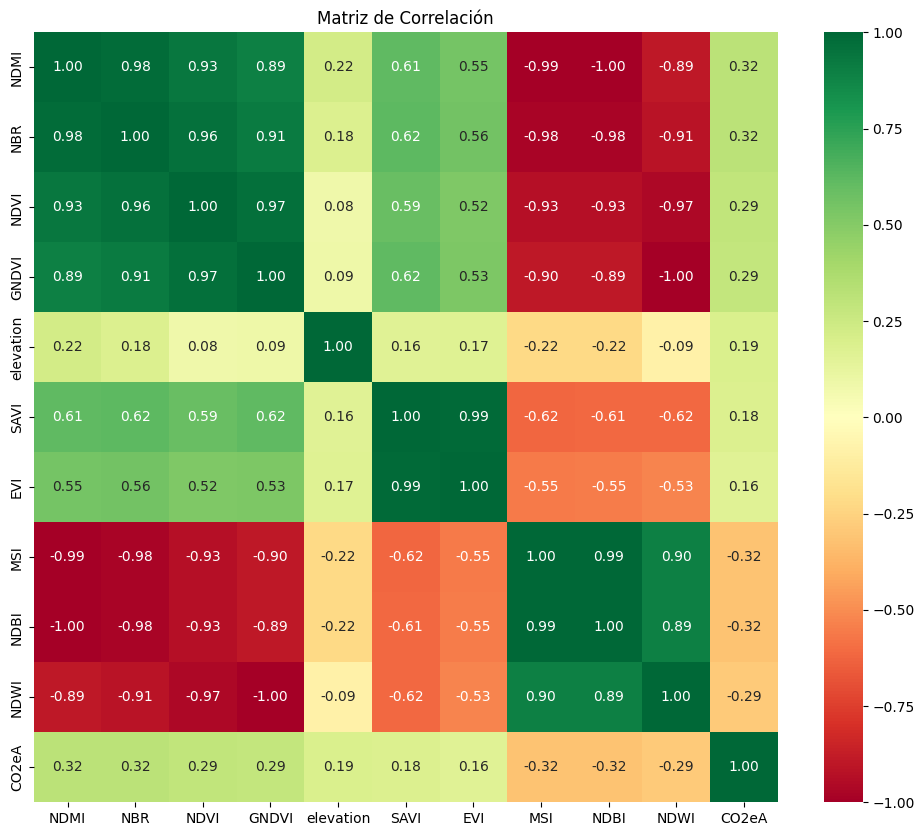

In [14]:
#@title Análisis de Correlación
corr = df[variables + [target]].corr()

plt.figure(figsize=(12,10))

sns.heatmap(
    corr,
    annot=True,
    cmap="RdYlGn",
    fmt=".2f"
)

plt.title("Matriz de Correlación")
plt.show()


# 10. ¿Qué algoritmo se puede utilizar como baseline?
La evaluación incluyó diferentes algoritmos de regresión considerados como modelos baseline para la estimación de CO2eA. Los modelos seleccionados fueron Regresión Lineal, Ridge Regression, Lasso Regression y Elastic Net, los cuales representan enfoques clásicos y regularizados basados en relaciones lineales entre las variables predictoras y la variable objetivo. La implementación de estos algoritmos permitió establecer una línea base de desempeño para comparar posteriormente modelos más complejos, además de analizar la capacidad predictiva de las variables espectrales, biofísicas y ambientales utilizadas en el estudio.

# 11. División Train Validation Test
La partición del conjunto de datos permitió dividir la información en tres subconjuntos independientes destinados al entrenamiento, validación y prueba de los modelos de Machine Learning. Inicialmente, el dataset fue separado en un 50% para entrenamiento y un 50% temporal; posteriormente, este último subconjunto se dividió nuevamente en partes iguales para obtener 25% de validación y 25% de prueba. Esta estrategia facilitó el entrenamiento de los algoritmos, el ajuste y evaluación de su capacidad de generalización utilizando datos no observados durante el entrenamiento, contribuyendo a reducir el riesgo de sobreajuste y proporcionando una evaluación más robusta del desempeño predictivo de los modelos.

In [16]:
#@title División Train Validation Test
X_train, X_temp, y_train, y_temp = train_test_split(
    X,
    y,
    test_size=0.50,
    random_state=42
)

X_val, X_test, y_val, y_test = train_test_split(
    X_temp,
    y_temp,
    test_size=0.50,
    random_state=42
)

print("Training:", X_train.shape)
print("Validation:", X_val.shape)
print("Testing:", X_test.shape)

Training: (8140, 10)
Validation: (4070, 10)
Testing: (4071, 10)


# 12. Preprocesamiento
El preprocesamiento de las variables numéricas se realizó mediante un pipeline automatizado con el objetivo de garantizar una preparación adecuada de los datos antes del entrenamiento de los modelos de Machine Learning. El proceso incluyó la imputación de valores faltantes utilizando la mediana de cada variable, estrategia que reduce la influencia de valores atípicos y preserva la estabilidad de los datos. Posteriormente, las variables fueron normalizadas en un rango entre 0 y 1 mediante MinMaxScaler, permitiendo que todas las características mantuvieran una escala comparable y favoreciendo la estabilidad, convergencia y desempeño de los algoritmos. Finalmente, la implementación de ColumnTransformer permitió organizar y aplicar de manera estructurada el flujo de transformación sobre las variables seleccionadas del dataset.

In [17]:
#@title Preprocesamiento
numeric_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", MinMaxScaler())
])

preprocessor = ColumnTransformer(
    transformers=[
        ("num", numeric_transformer, variables)
    ]
)

# 13. Modelos
La implementación del conjunto de modelos de regresión permitió evaluar diferentes enfoques baseline dentro del proceso de aprendizaje automático para la estimación de CO2eA. Los algoritmos seleccionados incluyeron Regresión Lineal, Ridge, Lasso y Elastic Net, los cuales incorporan distintas estrategias de regularización orientadas a mejorar la capacidad de generalización y reducir el riesgo de sobreajuste. La organización de los modelos en una estructura tipo diccionario facilitó su entrenamiento, comparación y evaluación de manera automatizada, permitiendo desarrollar un flujo de trabajo eficiente y reproducible dentro del notebook.

In [18]:
#@title Modelos
models = {
    "LinearRegression": LinearRegression(),
    "Ridge": Ridge(alpha=1.0),
    "Lasso": Lasso(alpha=0.01),
    "ElasticNet": ElasticNet(alpha=0.01, l1_ratio=0.5)
}


# 14. Función de evaluación
La función personalizada evaluate_model permitió calcular de manera automatizada las principales métricas utilizadas para evaluar el desempeño de los modelos de regresión. A partir de los valores observados y predichos, se calcularon el $RMSE$ (Root Mean Squared Error), el $MAE$ (Mean Absolute Error) y el coeficiente de determinación $R^2$, métricas fundamentales para cuantificar el nivel de error, precisión y capacidad explicativa de los algoritmos. La implementación de esta función facilitó la comparación objetiva entre los diferentes modelos evaluados y permitió estandarizar el proceso de evaluación dentro del flujo de trabajo del análisis de Machine Learning.

In [19]:
#@title Función de evaluación
def evaluate_model(y_true, y_pred):

    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    mae = mean_absolute_error(y_true, y_pred)
    r2 = r2_score(y_true, y_pred)

    return rmse, mae, r2


# 15. Entrenamiento y evaluación
El entrenamiento y evaluación de los modelos permitió comparar el desempeño predictivo de los algoritmos baseline utilizados para la estimación de CO2eA. Los resultados obtenidos mostraron que los modelos Linear Regression, Ridge y Lasso presentaron comportamientos muy similares, alcanzando valores de $R^2$
cercanos a 0.11 en entrenamiento y aproximadamente 0.10–0.13 en validación y prueba. En particular, Linear Regression obtuvo el mayor valor de $R^2$  en el conjunto de prueba ($R^2$=0.133306), acompañado de un $RMSE$ de 127.28 y un $MAE$ de 95.53. Por su parte, Elastic Net presentó el desempeño más bajo entre los modelos evaluados, registrando mayores errores y menor capacidad explicativa. Asimismo, los valores de Gap_$R^2$  fueron pequeños y cercanos a cero en todos los casos, indicando que no existe un sobreajuste severo y que los modelos mantienen una capacidad de generalización relativamente estable entre entrenamiento y validación. Sin embargo, los bajos valores globales de $R^2$ sugieren la presencia de underfitting, indicando que las relaciones entre las variables espectrales, biofísicas, topográficas y climáticas con CO2eA son complejas y posiblemente no lineales. Finalmente, la organización de todos los resultados en el DataFrame results_df facilitó la comparación objetiva y sistemática del desempeño de los diferentes algoritmos evaluados.

In [20]:
#@title Entrenamiento y evaluación
results = []

trained_models = {}

for name, model in models.items():

    pipeline = Pipeline(steps=[
        ("preprocessor", preprocessor),
        ("model", model)
    ])

    pipeline.fit(X_train, y_train)

    trained_models[name] = pipeline

    pred_train = pipeline.predict(X_train)
    pred_val = pipeline.predict(X_val)
    pred_test = pipeline.predict(X_test)

    rmse_train, mae_train, r2_train = evaluate_model(y_train, pred_train)
    rmse_val, mae_val, r2_val = evaluate_model(y_val, pred_val)
    rmse_test, mae_test, r2_test = evaluate_model(y_test, pred_test)

    gap_r2 = r2_val - r2_train

    results.append([
        name,
        rmse_train,
        mae_train,
        r2_train,
        rmse_val,
        mae_val,
        r2_val,
        rmse_test,
        mae_test,
        r2_test,
        gap_r2
    ])

results_df = pd.DataFrame(results, columns=[
    "Model",
    "RMSE_Train",
    "MAE_Train",
    "R2_Train",
    "RMSE_Validation",
    "MAE_Validation",
    "R2_Validation",
    "RMSE_Test",
    "MAE_Test",
    "R2_Test",
    "Gap_R2"
])

results_df

,Model,RMSE_Train,MAE_Train,R2_Train,RMSE_Validation,MAE_Validation,R2_Validation,RMSE_Test,MAE_Test,R2_Test,Gap_R2
0,LinearRegression,124.291396,94.201496,0.119282,129.949732,95.423827,0.108325,127.276862,95.530039,0.133306,-0.010957
1,Ridge,124.300291,94.192714,0.119156,129.921000,95.413397,0.108720,127.292590,95.528688,0.133092,-0.010436
2,Lasso,124.298225,94.192993,0.119185,129.935078,95.416254,0.108526,127.293618,95.532366,0.133078,-0.010659
3,ElasticNet,124.520107,94.301698,0.116038,130.095872,95.623889,0.106319,127.553550,95.661470,0.129534,-0.009719


# 16. ¿Se puede determinar la importancia de las características?
La importancia de las variables predictoras puede ser evaluada mediante la técnica de Permutation Importance. Este método permite medir la contribución de cada característica al desempeño del modelo al alterar aleatoriamente los valores de una variable y observar el impacto en las métricas de predicción. De esta manera, es posible identificar cuáles variables tienen mayor influencia en la estimación de CO2eA y comprender mejor el comportamiento del modelo de Machine Learning.

In [21]:

#@title ¿Se puede determinar la importancia de las características?
print("Sí. Se utilizará permutation importance.")


Sí. Se utilizará permutation importance.


# 17. Ranking
El ranking de los algoritmos evaluados se basa en su desempeño sobre el conjunto de prueba. Para ello, se calculan posiciones individuales utilizando las métricas RMSE, MAE y R², considerando que menores valores de error y mayores valores de R² representan un mejor desempeño. Posteriormente, se genera un puntaje global denominado Final_Rank, obtenido mediante la suma de los rankings individuales, lo que permite ordenar y comparar objetivamente los modelos para identificar el algoritmo con mejor capacidad predictiva y generalización.

In [22]:
#@title Ranking de Algoritmos
ranking = results_df.copy()

ranking["Rank_RMSE"] = ranking["RMSE_Test"].rank(ascending=True)
ranking["Rank_MAE"] = ranking["MAE_Test"].rank(ascending=True)
ranking["Rank_R2"] = ranking["R2_Test"].rank(ascending=False)

ranking["Final_Rank"] = (
    ranking["Rank_RMSE"] +
    ranking["Rank_MAE"] +
    ranking["Rank_R2"]
)

ranking = ranking.sort_values("Final_Rank")

ranking

,Model,RMSE_Train,MAE_Train,R2_Train,RMSE_Validation,MAE_Validation,R2_Validation,RMSE_Test,MAE_Test,R2_Test,Gap_R2,Rank_RMSE,Rank_MAE,Rank_R2,Final_Rank
0,LinearRegression,124.291396,94.201496,0.119282,129.949732,95.423827,0.108325,127.276862,95.530039,0.133306,-0.010957,1.0,2.0,1.0,4.0
1,Ridge,124.300291,94.192714,0.119156,129.921000,95.413397,0.108720,127.292590,95.528688,0.133092,-0.010436,2.0,1.0,2.0,5.0
2,Lasso,124.298225,94.192993,0.119185,129.935078,95.416254,0.108526,127.293618,95.532366,0.133078,-0.010659,3.0,3.0,3.0,9.0
3,ElasticNet,124.520107,94.301698,0.116038,130.095872,95.623889,0.106319,127.553550,95.661470,0.129534,-0.009719,4.0,4.0,4.0,12.0


# 18. Mejor algoritmo
La selección del algoritmo de mejor desempeño se realiza a partir del ranking final obtenido durante la evaluación de los modelos. El modelo con menor valor de Final_Rank es identificado como el mejor algoritmo, considerando conjuntamente las métricas RMSE, MAE y R². Posteriormente, dicho modelo es almacenado para su análisis e interpretación, permitiendo utilizarlo en etapas posteriores como predicción, evaluación detallada e importancia de variables.

In [23]:
#@title Algoritmo de Mejor Desempeño
best_model_name = ranking.iloc[0]["Model"]

print("Mejor algoritmo:", best_model_name)

best_model = trained_models[best_model_name]

Mejor algoritmo: LinearRegression


# 19. Importancia de variables
El análisis de importancia de variables permite identificar cuáles características tienen mayor influencia en el desempeño del mejor modelo seleccionado. Para ello, se calcula la importancia promedio de cada variable mediante múltiples permutaciones aleatorias sobre el conjunto de prueba, evaluando el impacto que tiene cada característica en la capacidad predictiva del modelo. Finalmente, las variables son organizadas de mayor a menor importancia, facilitando la interpretación de los factores más relevantes en la estimación de CO2eA.

In [24]:
#@title Importancia de Variables
result = permutation_importance(
    best_model,
    X_test,
    y_test,
    n_repeats=10,
    random_state=42
)

importance = pd.DataFrame({
    "Variable": variables,
    "Importance": result.importances_mean
})

importance = importance.sort_values(
    by="Importance",
    ascending=False
)

importance

,Variable,Importance
1,NBR,0.141078
7,MSI,0.063617
4,elevation,0.041733
0,NDMI,0.025943
8,NDBI,0.025943
6,EVI,0.005152
3,GNDVI,0.004832
9,NDWI,0.004832
5,SAVI,0.003502
2,NDVI,0.001105


# 20. Gráfica de importancia
La gráfica de importancia de variables permitió visualizar de manera comparativa la contribución de cada característica en el desempeño del mejor modelo seleccionado, correspondiente a Linear Regression. Los resultados mostraron que la variable NBR presentó la mayor influencia en la predicción de CO2eA, seguida por MSI y elevación, indicando que los índices relacionados con severidad de vegetación, estrés hídrico y condiciones topográficas tienen un papel relevante en la estimación de carbono aéreo. Asimismo, variables como NDMI y NDBI mostraron una contribución intermedia, mientras que índices como NDVI, SAVI, NDWI, GNDVI y EVI presentaron una influencia menor dentro del modelo. La representación mediante un gráfico de barras facilitó la interpretación visual de la relevancia de las variables y permitió identificar los factores espectrales y ambientales más asociados al almacenamiento de carbono forestal.

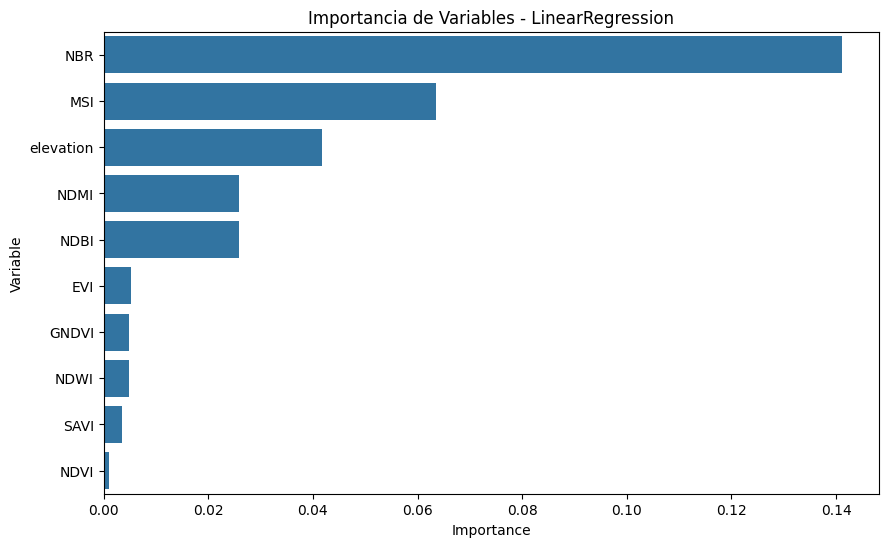

In [25]:
#@title Gráfica de Importancia
plt.figure(figsize=(10,6))

sns.barplot(
    data=importance,
    x="Importance",
    y="Variable"
)

plt.title(f"Importancia de Variables - {best_model_name}")

plt.show()


# 21. ¿Existe overfitting o underfitting?
La comparación entre R2_Train, R2_Validation y R2_Test indica que no existe un problema fuerte de overfitting, ya que los valores de desempeño son muy similares entre entrenamiento, validación y prueba. Además, los valores de Gap_R2 son pequeños y cercanos a cero, lo que sugiere que los modelos mantienen un comportamiento relativamente consistente entre los diferentes subconjuntos de datos.

Sin embargo, los valores de R² son bajos en todos los modelos (≈ 0.10–0.13), lo que indica un problema de underfitting. Esto significa que los algoritmos lineales utilizados no están capturando adecuadamente la complejidad y relaciones no lineales presentes en los datos para explicar la variabilidad de CO2eA.

Los resultados sugieren que:

Los modelos presentan buena estabilidad y generalización.
No existe sobreajuste significativo.
La capacidad predictiva es limitada debido a subajuste (underfitting).
Es recomendable utilizar algoritmos más complejos o realizar ingeniería de características (feature engineering), incluyendo:
Variables derivadas.
Interacciones entre índices espectrales.
Transformaciones no lineales.
Modelos basados en árboles y ensambles como Random Forest, XGBoost o Gradient Boosting.

In [26]:

#@title ¿Existe overfitting o underfitting?
results_df[["Model", "R2_Train", "R2_Validation", "R2_Test", "Gap_R2"]]


,Model,R2_Train,R2_Validation,R2_Test,Gap_R2
0,LinearRegression,0.119282,0.108325,0.133306,-0.010957
1,Ridge,0.119156,0.108720,0.133092,-0.010436
2,Lasso,0.119185,0.108526,0.133078,-0.010659
3,ElasticNet,0.116038,0.106319,0.129534,-0.009719


# 22. Interpretación del GAP
La interpretación del Gap_R2 permite evaluar la capacidad de generalización de los modelos de Machine Learning. Un gap pequeño y cercano a cero indica que el modelo mantiene un desempeño similar entre entrenamiento y validación, lo que sugiere una buena generalización. En contraste, un gap muy negativo puede indicar sobreajuste (overfitting), donde el modelo aprende demasiado los datos de entrenamiento y pierde capacidad predictiva sobre datos nuevos. Asimismo, valores bajos de R² en entrenamiento, validación y prueba reflejan un posible problema de subajuste (underfitting), indicando que el modelo no logra capturar adecuadamente la relación entre las variables predictoras y la variable objetivo CO2eA.

# 23. ¿Cuál es la métrica adecuada?
Las métricas seleccionadas para la evaluación de los modelos de regresión son RMSE, MAE y R², ya que permiten analizar diferentes aspectos del desempeño predictivo. El RMSE mide la magnitud promedio del error penalizando más los errores grandes, el MAE representa el error absoluto promedio entre valores reales y predichos, y el R² evalúa la proporción de variabilidad explicada por el modelo. El uso conjunto de estas métricas proporciona una evaluación más completa y confiable de la capacidad predictiva y generalización de los algoritmos de Machine Learning.

# 24. ¿Cuál debería ser el desempeño mínimo?
El desempeño mínimo esperado en un modelo de regresión depende del contexto y complejidad de los datos; sin embargo, generalmente se considera deseable un valor de R² superior a 0.50, indicando que el modelo explica al menos el 50% de la variabilidad de la variable objetivo. Asimismo, un RMSE menor que la desviación estándar de la variable objetivo sugiere que las predicciones presentan un error aceptable respecto a la dispersión natural de los datos. Finalmente, valores de MAE similares entre entrenamiento, validación y prueba reflejan estabilidad y buena capacidad de generalización del modelo.

# 25. Observado vs Predicho
La gráfica de valores observados versus predichos permite evaluar visualmente el desempeño del mejor modelo seleccionado sobre el conjunto de prueba. En esta representación, los valores reales de CO2eA se comparan con las predicciones generadas por el modelo, facilitando la identificación de patrones de ajuste, dispersión y posibles errores de predicción. Un comportamiento ideal se observa cuando los puntos se aproximan a una línea diagonal, indicando que los valores predichos son similares a los valores observados y reflejando una mayor capacidad predictiva del modelo.

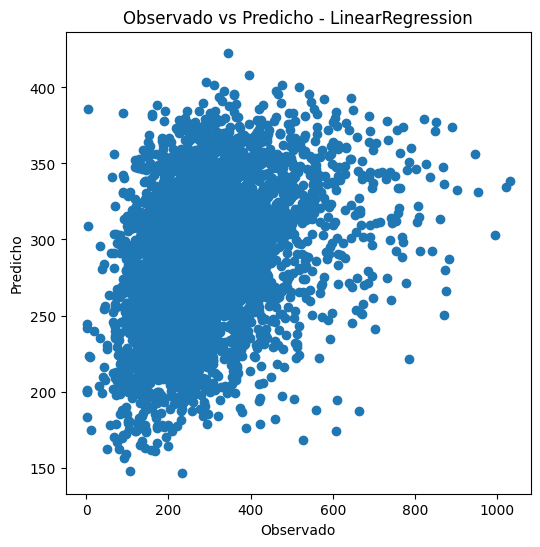

In [30]:
#@title Observado vs Predicho
pred_best = best_model.predict(X_test)

plt.figure(figsize=(6,6))

plt.scatter(y_test, pred_best)

plt.xlabel("Observado")
plt.ylabel("Predicho")

plt.title(f"Observado vs Predicho - {best_model_name}")

plt.show()

# 26. Residuales
La gráfica de distribución de residuales permitió evaluar el comportamiento de los errores del modelo mediante la diferencia entre los valores observados y los valores predichos (Residual=y_real −y_predicho). Los resultados mostraron una distribución concentrada alrededor de cero, aunque con una ligera asimetría positiva y presencia de colas largas hacia valores elevados, lo que sugiere que el modelo presenta dificultades para capturar adecuadamente algunos valores extremos de CO2eA. La forma general de la distribución indica que no existe un sobreajuste severo; sin embargo, la dispersión observada y la amplitud de los errores son consistentes con un escenario de underfitting, asociado a la limitada capacidad explicativa de los modelos baseline lineales. Asimismo, la presencia de asimetrías y residuales elevados sugiere la existencia de relaciones no lineales y patrones complejos entre las variables espectrales, biofísicas y ambientales utilizadas en el análisis. En el contexto forestal, esta evaluación resulta especialmente relevante debido a que índices espectrales como NDVI, NDMI, SAVI, EVI, MSI y NBR, así como variables topográficas como elevación, pueden presentar comportamientos altamente no lineales en relación con el almacenamiento de carbono aéreo, lo que justifica la necesidad de incorporar nuevas variables biofísicas y modelos más avanzados de Machine Learning para mejorar la capacidad predictiva.

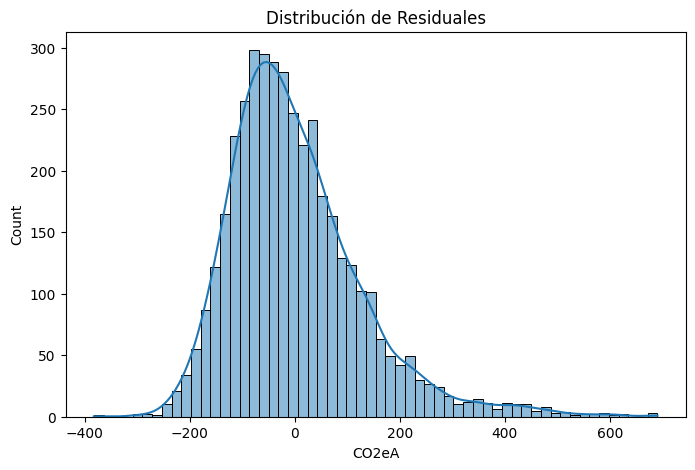

In [31]:
#@title Grafica de Residuales
residuals = y_test - pred_best

plt.figure(figsize=(8,5))

sns.histplot(residuals, kde=True)

plt.title("Distribución de Residuales")

plt.show()

# 27. Conclusiones
Las evaluaciones realizadas con los modelos baseline de regresión (Linear Regression, Ridge, Lasso y ElasticNet) mostraron desempeños relativamente similares y limitados, obteniendo valores bajos de $R^2$ cercanos a 0.10–0.13, lo que indica que las variables actuales explican únicamente una parte reducida de la variabilidad de CO2eA. Entre los modelos evaluados, Ridge y Linear Regression presentaron el mejor equilibrio entre capacidad predictiva y generalización, al registrar menores valores de RMSE y mejores resultados en los conjuntos de validación y prueba. Asimismo, los valores reducidos de Gap_$R^2$  cercanos a cero evidenciaron que no existe un sobreajuste severo, ya que el comportamiento de los modelos se mantuvo relativamente estable entre entrenamiento y validación. Sin embargo, el bajo desempeño general sugiere la presencia de underfitting, indicando que las relaciones entre las variables espectrales, biofísicas, topográficas y climáticas con el carbono forestal son altamente complejas y no lineales. De manera particular, los índices espectrales utilizados no generaron resultados suficientemente adecuados para explicar con precisión la variabilidad de CO2eA bajo modelos lineales baseline. El análisis de residuales permitió identificar el comportamiento de los errores y detectar posibles patrones asociados con heterocedasticidad o relaciones no modeladas, mientras que la evaluación de importancia de variables mostró que índices como NBR, MSI y elevación presentan una contribución relevante dentro de los modelos evaluados. Finalmente, los resultados sugieren la necesidad de incorporar nuevas variables con mayor relación biofísica directa con el almacenamiento de carbono, particularmente variables asociadas con biomasa forestal y densidad de árboles por hectárea, las cuales podrían mejorar significativamente la capacidad predictiva de los algoritmos de Machine Learning. Asimismo, la implementación de técnicas de Feature Engineering y el uso de modelos no lineales, como Random Forest, Gradient Boosting o redes neuronales, representan estrategias prometedoras para incrementar el desempeño y la capacidad de generalización en la estimación de CO2eA.